## Clasificación de Series Temporales: BiLSTM
### Caso: Reconocimiento de Actividad Humana (HAR)

**Objetivo:** Clasificar actividades físicas mediante señales de sensores (acelerómetro/giroscopio).
* **Problema:** Clasificación Multi-clase (6 actividades).
* **Entrada:** Ventanas de 2.56 segundos (9 sensores en paralelo).
* **Modelo:** Red LSTM Bidireccional (BiLSTM).

#### 1. Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Librerias cargadas correctamente.')
print(f'PyTorch version : {torch.__version__}')
print(f'Dispositivo     : {"cuda" if torch.cuda.is_available() else "cpu"}')

Librerias cargadas correctamente.
PyTorch version : 2.5.1
Dispositivo     : cuda


#### 2. Dataset y Estructura de Datos
* **Origen:** Sensores de Smartphone (50 Hz).
* **Forma del Tensor:** `(muestras, 128 pasos, 9 canales)`.
* **Clases (6):** Caminar, Subir/Bajar escaleras, Sentado, Parado y Acostado.
* **Preprocesamiento:** Ventanas de 128 muestras con 50% de solapamiento.

In [2]:
# ── Descarga automática del dataset UCI HAR ───────────────────────────────────
URL  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip'
DEST = 'UCI_HAR_Dataset.zip'
DIR  = 'UCI HAR Dataset'

if not os.path.exists(DIR):
    print('Descargando dataset...')
    urllib.request.urlretrieve(URL, DEST)
    print('Descomprimiendo...')
    with zipfile.ZipFile(DEST, 'r') as zf:
        zf.extractall('.')
    print('Dataset listo.')
else:
    print('Dataset ya descargado.')

Descargando dataset...
Descomprimiendo...
Dataset listo.


In [3]:
# ── Definición de las 9 señales de sensores ───────────────────────────────────
LABELS = [
    'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS',
    'SITTING', 'STANDING', 'LAYING'
]

SIGNALS = [
    'body_acc_x_',  'body_acc_y_',  'body_acc_z_',     # aceleracion del cuerpo
    'body_gyro_x_', 'body_gyro_y_', 'body_gyro_z_',    # giroscopio
    'total_acc_x_', 'total_acc_y_', 'total_acc_z_'     # aceleracion total
]

N_FEATURES  = len(SIGNALS)   # 9 canales de sensores
N_CLASSES   = len(LABELS)    # 6 actividades
SEQ_LEN     = 128             # pasos temporales por ventana (2.56 seg a 50 Hz)
BATCH_SIZE  = 64

print(f'Canales de sensores : {N_FEATURES}')
print(f'Clases              : {N_CLASSES}')
print(f'Pasos temporales    : {SEQ_LEN}')


def cargar_senales(split: str) -> np.ndarray:
    """
    Carga las 9 señales de sensores para 'train' o 'test'.
    Retorna un array de forma (muestras, seq_len=128, n_features=9).
    """
    ruta_base = f'{DIR}/{split}/Inertial Signals/'
    senales = []
    for senal in SIGNALS:
        ruta = ruta_base + senal + split + '.txt'
        datos = np.loadtxt(ruta, dtype=np.float32)   # (muestras, 128)
        senales.append(datos)
    # Apilar: (9, muestras, 128) -> transponer -> (muestras, 128, 9)
    return np.transpose(np.array(senales), (1, 2, 0))


def cargar_etiquetas(split: str) -> np.ndarray:
    """
    Carga las etiquetas y las convierte a indices 0-based para CrossEntropyLoss.
    El dataset original usa codigos 1-6; restamos 1 para obtener 0-5.
    """
    ruta = f'{DIR}/{split}/y_{split}.txt'
    return np.loadtxt(ruta, dtype=np.int64) - 1   # 1-6 → 0-5


# Carga efectiva de datos
X_train = cargar_senales('train')    # (7352, 128, 9)
y_train = cargar_etiquetas('train')  # (7352,)
X_test  = cargar_senales('test')     # (2947, 128, 9)
y_test  = cargar_etiquetas('test')   # (2947,)

print(f'\nX_train : {X_train.shape}  -> (muestras, seq_len, features)')
print(f'y_train : {y_train.shape}  -> (muestras,)')
print(f'X_test  : {X_test.shape}   -> (muestras, seq_len, features)')
print(f'y_test  : {y_test.shape}   -> (muestras,)')
print(f'\nClases unicas en y_train: {np.unique(y_train)}  (0-5)')

Canales de sensores : 9
Clases              : 6
Pasos temporales    : 128

X_train : (7352, 128, 9)  -> (muestras, seq_len, features)
y_train : (7352,)  -> (muestras,)
X_test  : (2947, 128, 9)   -> (muestras, seq_len, features)
y_test  : (2947,)   -> (muestras,)

Clases unicas en y_train: [0 1 2 3 4 5]  (0-5)


#### 3. Exploración y Visualización del Dataset

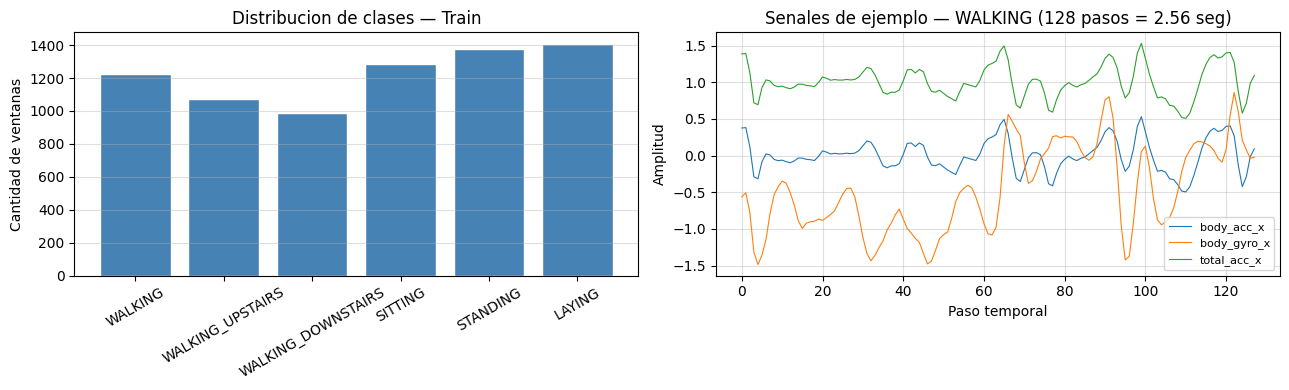

In [4]:
# ── Distribución de clases en Train ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

conteos = np.bincount(y_train)
axes[0].bar(LABELS, conteos, color='steelblue', edgecolor='white')
axes[0].set_title('Distribucion de clases — Train')
axes[0].set_ylabel('Cantidad de ventanas')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.4)

# Señales del primer ejemplo (clase 0 = WALKING)
idx_walking = np.where(y_train == 0)[0][0]
axes[1].plot(X_train[idx_walking, :, 0], label='body_acc_x', linewidth=0.8)
axes[1].plot(X_train[idx_walking, :, 3], label='body_gyro_x', linewidth=0.8)
axes[1].plot(X_train[idx_walking, :, 6], label='total_acc_x', linewidth=0.8)
axes[1].set_title('Senales de ejemplo — WALKING (128 pasos = 2.56 seg)')
axes[1].set_xlabel('Paso temporal'); axes[1].set_ylabel('Amplitud')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

#### 4. Preparación de Tensores y DataLoaders

**Punto clave para clasificación:**  
Las etiquetas `y` deben ser `torch.LongTensor` (enteros 64-bit), ya que `nn.CrossEntropyLoss` espera índices de clase, no vectores one-hot.

In [5]:
class HARDataset(Dataset):
    """
    Dataset para el problema de clasificacion HAR.

    X : FloatTensor de forma (seq_len=128, n_features=9) por muestra
    y : LongTensor  de forma ()  —  indice de clase 0-5
         LongTensor es obligatorio para nn.CrossEntropyLoss
    """
    def __init__(self, X: np.ndarray, y: np.ndarray = None):
        self.X = torch.tensor(X, dtype=torch.float32)   # (muestras, 128, 9)
        self.y = torch.tensor(y, dtype=torch.long) if y is not None else None
        # torch.long == torch.int64 == LongTensor, requerido por CrossEntropyLoss

    def __len__(self):  return len(self.X)

    def __getitem__(self, ix):
        return (self.X[ix], self.y[ix]) if self.y is not None else self.X[ix]


dataloader = {
    'train': DataLoader(HARDataset(X_train, y_train), shuffle=True,  batch_size=BATCH_SIZE),
    'eval' : DataLoader(HARDataset(X_test,  y_test),  shuffle=False, batch_size=BATCH_SIZE),
    'test' : DataLoader(HARDataset(X_test),            shuffle=False, batch_size=BATCH_SIZE),
}

# Verificar formas de un batch
Xb, yb = next(iter(dataloader['train']))
print(f'Batch X : {Xb.shape}  -> (batch=64, seq_len=128, features=9)')
print(f'Batch y : {yb.shape}  -> (batch=64,)  tipo: {yb.dtype}  (LongTensor)')
print(f'Valores unicos en y del batch: {yb.unique().tolist()}')

Batch X : torch.Size([64, 128, 9])  -> (batch=64, seq_len=128, features=9)
Batch y : torch.Size([64])  -> (batch=64,)  tipo: torch.int64  (LongTensor)
Valores unicos en y del batch: [0, 1, 2, 3, 4, 5]


#### 3. Arquitectura del Modelo: BiLSTM
Una **BiLSTM** procesa la secuencia en ambas direcciones simultáneamente:
* **Forward:** Lee del inicio al fin ($t=1 \to 128$).
* **Backward:** Lee del fin al inicio ($t=128 \to 1$).
* **Salida:** Se concatenan ambos estados ocultos ($h_t^{bi} = [\overrightarrow{h_t} \| \overleftarrow{h_t}]$).

**Flujo de Datos:**
1. **Entrada:** `(Batch, 128, 9)`
2. **BiLSTM:** 2 capas, 128 neuronas (Salida total: **256** por bidireccionalidad).
3. **Dropout (0.3):** Regularización contra sobreajuste.
4. **Capa Lineal:** `(256 → 6)` para obtener los logits de las actividades.

In [6]:
class BiLSTMModel(nn.Module):
    """
    LSTM Bidireccional de 2 capas para clasificacion de actividades (HAR).

    Entrada : (batch, seq_len=128, input_size=9)
    Salida  : (batch, n_classes=6)  — logits sin softmax

    ATENCION sobre bidireccional:
    Al usar bidirectional=True, la dimension de salida de la LSTM es
    2 * hidden_size. La capa fc DEBE recibir ese tamano duplicado.
    """
    def __init__(
        self,
        input_size:  int = N_FEATURES,    # 9 canales de sensores
        hidden_size: int = 128,
        num_layers:  int = 2,
        n_classes:   int = N_CLASSES,     # 6 actividades
        dropout:     float = 0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size   = input_size,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            dropout      = dropout,
            batch_first  = True,
            bidirectional = True          # ← activa la lectura en ambas direcciones
        )

        self.dropout = nn.Dropout(dropout)

        # Al ser bidireccional, el estado oculto final tiene 2 * hidden_size
        self.fc = nn.Linear(2 * hidden_size, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x   : (batch, seq_len, input_size)
        # out : (batch, seq_len, 2 * hidden_size)  — concatenacion de ambas dirs
        # h_n : (num_layers * 2, batch, hidden_size)
        out, (h_n, c_n) = self.lstm(x)

        # Tomamos solo el ULTIMO paso temporal de la secuencia
        # Este vector ya contiene informacion de ambas direcciones:
        #   - forward  vio t=1..128
        #   - backward vio t=128..1
        last = out[:, -1, :]          # (batch, 2 * hidden_size)

        last = self.dropout(last)     # regularizacion
        return self.fc(last)          # (batch, n_classes=6)  — logits


modelo = BiLSTMModel()
print(modelo)
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'\nParametros entrenables : {total_params:,}')

# Verificar dimensiones con un batch de prueba
with torch.no_grad():
    salida_prueba = modelo(torch.randn(8, SEQ_LEN, N_FEATURES))
    print(f'Entrada de prueba      : (8, {SEQ_LEN}, {N_FEATURES})')
    print(f'Salida de prueba       : {salida_prueba.shape}  -> (batch=8, clases=6)')

BiLSTMModel(
  (lstm): LSTM(9, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=6, bias=True)
)

Parametros entrenables : 539,142
Entrada de prueba      : (8, 128, 9)
Salida de prueba       : torch.Size([8, 6])  -> (batch=8, clases=6)


#### 6. Pipeline de Entrenamiento para Clasificación

**Diferencias clave respecto a la regresión (USD/BRL):**

| Concepto | Regresión (MLP/LSTM) | Clasificación (BiLSTM HAR) |
|---|---|---|
| Función de pérdida | `MSELoss` | `CrossEntropyLoss` |
| Salida del modelo | 1 valor continuo | 6 logits (uno por clase) |
| Métrica principal | RMSE / MAE (BRL) | Accuracy (%) |
| Tipo de `y` | `FloatTensor` | `LongTensor` (índices) |

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo de computo: {device}')


def fit(model: nn.Module, dataloader: dict, epochs: int = 20, lr: float = 1e-3):
    """
    Bucle de entrenamiento para CLASIFICACION.

    Usa CrossEntropyLoss (no MSE) y calcula Accuracy como metrica principal.
    CrossEntropyLoss combina internamente LogSoftmax + NLLLoss,
    por lo que la capa fc NO debe aplicar Softmax.
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()   # ← CLASIFICACION: no MSE
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    bar  = tqdm(range(1, epochs + 1), desc='BiLSTM')

    for epoch in bar:
        # ── Fase de entrenamiento ──────────────────────────────────────────────
        model.train()
        losses, correctos, total = [], 0, 0
        for X_b, y_b in dataloader['train']:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(X_b)                      # (batch, 6)
            loss   = criterion(logits, y_b)          # y_b es LongTensor
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
            # Calcular accuracy: clase predicha = argmax de los logits
            preds     = logits.argmax(dim=1)
            correctos += (preds == y_b).sum().item()
            total     += len(y_b)

        train_loss = np.mean(losses)
        train_acc  = correctos / total

        # ── Fase de validacion ─────────────────────────────────────────────────
        model.eval()
        val_losses, val_correctos, val_total = [], 0, 0
        with torch.no_grad():
            for X_b, y_b in dataloader['eval']:
                X_b, y_b = X_b.to(device), y_b.to(device)
                logits   = model(X_b)
                val_losses.append(criterion(logits, y_b).item())
                preds        = logits.argmax(dim=1)
                val_correctos += (preds == y_b).sum().item()
                val_total     += len(y_b)

        val_loss = np.mean(val_losses)
        val_acc  = val_correctos / val_total

        hist['train_loss'].append(train_loss)
        hist['val_loss'].append(val_loss)
        hist['train_acc'].append(train_acc)
        hist['val_acc'].append(val_acc)

        bar.set_description(
            f'Ep {epoch:3d}  '
            f'loss {train_loss:.4f}  val_loss {val_loss:.4f}  '
            f'acc {train_acc:.3f}  val_acc {val_acc:.3f}'
        )

    return hist


print('Funcion fit definida para clasificacion.')
print('  Perdida : CrossEntropyLoss')
print('  Metrica : Accuracy')

Dispositivo de computo: cuda
Funcion fit definida para clasificacion.
  Perdida : CrossEntropyLoss
  Metrica : Accuracy


#### 7. Entrenamiento del Modelo

In [8]:
modelo = BiLSTMModel()   # instanciar modelo fresco
hist   = fit(modelo, dataloader, epochs=20, lr=1e-3)

Ep  20  loss 0.1232  val_loss 0.2459  acc 0.950  val_acc 0.920: 100%|██████████| 20/20 [00:55<00:00,  2.77s/it]


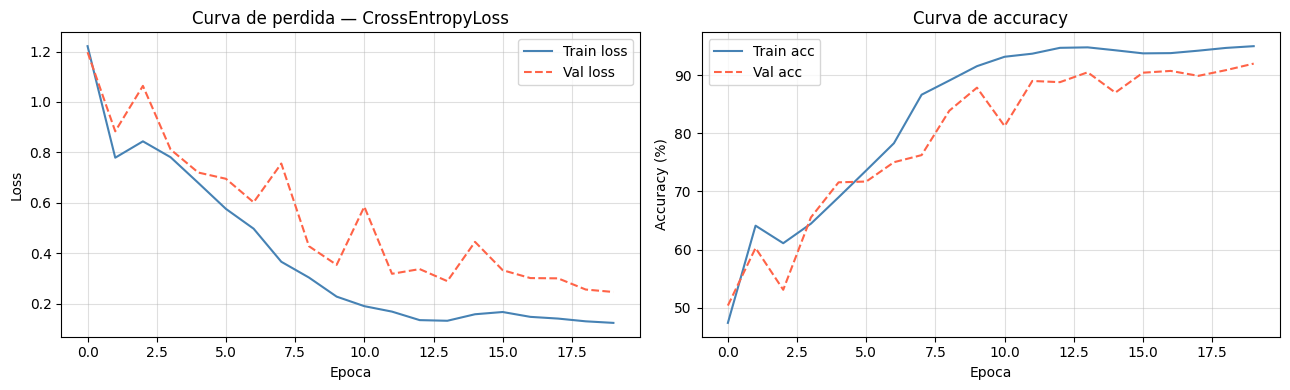

In [9]:
# ── Curvas de aprendizaje ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist['train_loss'], label='Train loss', color='steelblue')
axes[0].plot(hist['val_loss'],   label='Val loss',   color='tomato', linestyle='--')
axes[0].set_title('Curva de perdida — CrossEntropyLoss')
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot([a * 100 for a in hist['train_acc']], label='Train acc', color='steelblue')
axes[1].plot([a * 100 for a in hist['val_acc']],   label='Val acc',   color='tomato', linestyle='--')
axes[1].set_title('Curva de accuracy')
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

#### 8. Evaluación Final en el Conjunto de Test

In [10]:
# ── Evaluacion sobre el conjunto de test completo ────────────────────────────
modelo.eval()
todas_preds, todas_etiquetas = [], []

with torch.no_grad():
    for X_b in dataloader['test']:
        X_b    = X_b.to(device)
        logits = modelo(X_b)               # (batch, 6)
        preds  = logits.argmax(dim=1)      # clase con mayor logit
        todas_preds.extend(preds.cpu().numpy())

# Etiquetas reales (ya en 0-5)
todas_etiquetas = y_test

# ── Accuracy global ───────────────────────────────────────────────────────────
acc_global = accuracy_score(todas_etiquetas, todas_preds)

sep = '=' * 52
print(sep)
print(f'  EVALUACION FINAL — BiLSTM sobre Test Set')
print(sep)
print(f'  Muestras evaluadas : {len(todas_etiquetas)}')
print(f'  Accuracy global    : {acc_global * 100:.2f}%')
print(sep)
print()
print('Reporte por clase:')
print(classification_report(
    todas_etiquetas, todas_preds,
    target_names=LABELS, digits=4
))

  EVALUACION FINAL — BiLSTM sobre Test Set
  Muestras evaluadas : 2947
  Accuracy global    : 91.99%

Reporte por clase:
                    precision    recall  f1-score   support

           WALKING     0.9816    0.9677    0.9746       496
  WALKING_UPSTAIRS     0.9548    0.9873    0.9708       471
WALKING_DOWNSTAIRS     0.9630    0.9905    0.9765       420
           SITTING     0.8697    0.7475    0.8039       491
          STANDING     0.7792    0.8891    0.8306       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.9199      2947
         macro avg     0.9247    0.9220    0.9218      2947
      weighted avg     0.9228    0.9199    0.9198      2947



#### 9. Matriz de Confusión

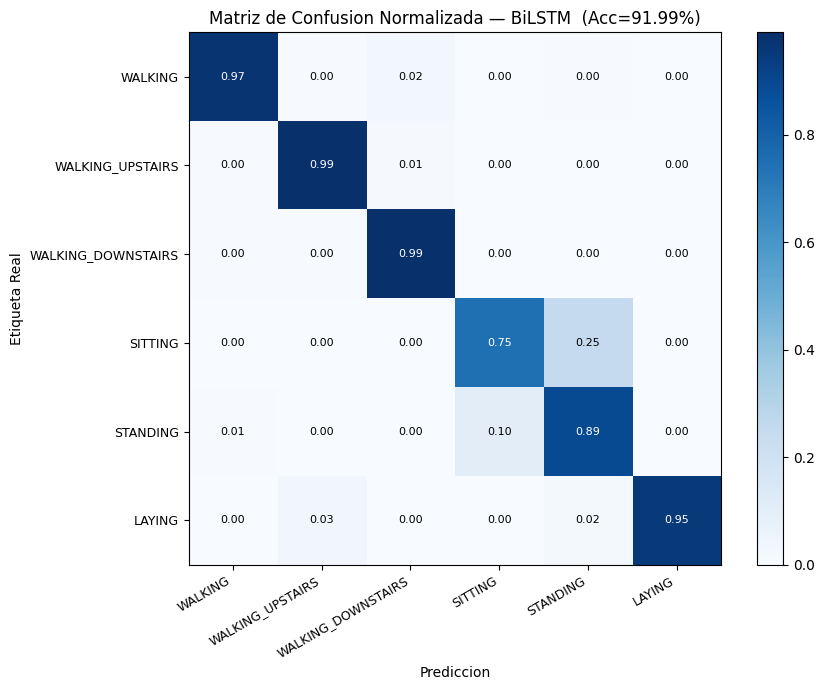

In [11]:
cm = confusion_matrix(todas_etiquetas, todas_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # normalizar por fila

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(LABELS, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(LABELS, fontsize=9)

thresh = cm_norm.max() / 2.0
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f'{cm_norm[i, j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='white' if cm_norm[i, j] > thresh else 'black')

ax.set_title(f'Matriz de Confusion Normalizada — BiLSTM  (Acc={acc_global*100:.2f}%)')
ax.set_xlabel('Prediccion'); ax.set_ylabel('Etiqueta Real')
plt.tight_layout()
plt.show()

#### 10. Justificación Teórica

---

#### ¿Por qué una LSTM Bidireccional es la arquitectura adecuada para este problema?

#### 1. La naturaleza de los datos: series temporales multivariadas con contexto bidireccional

El dataset HAR está compuesto por **ventanas fijas de 2.56 segundos** (128 muestras a 50 Hz) de 9 canales de sensores inerciales. Cada ventana es una **secuencia temporal completa y disponible en su totalidad** en el momento de la clasificación: el modelo tiene acceso simultáneo al instante $t=1$ y al $t=128$.## 4. Justificación Técnica: ¿Por qué BiLSTM?

**1. Contexto Completo:**
A diferencia del trading (donde el futuro es desconocido), en este dataset tenemos la "ventana" completa. Leer hacia atrás permite detectar cómo termina un movimiento para entender cómo empezó.

**2. BiLSTM vs. MLP:**
* El **MLP** aplana los datos (1,152 valores), perdiendo el orden temporal.
* La **BiLSTM** preserva la trayectoria dinámica del movimiento, permitiendo distinguir actividades con patrones similares (ej. caminar vs. subir escaleras).

**3. Versatilidad:**
Aunque nació para el lenguaje (NLP), la BiLSTM es ideal para cualquier señal con dependencias temporales: ECG médicos, vibraciones industriales o gestos deportivos.

**Configuración Final:**
`BiLSTM (2 capas) + Dropout (0.3) + Linear Classifier + CrossEntropyLoss`